# Data

## Read Data

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

base_path = Path("Data")
df = pd.read_csv(base_path/"2010-2025.csv", encoding = "utf-16", sep = r"\s+")
df.columns = ["name", "date", "close", "return", "turnover", "volume(thousands)", "market_cap(millions)"]
df["date"] = pd.to_datetime(df["date"], format  ="%Y%m%d")
df["return"] = pd.to_numeric(df["return"], errors = "coerce")
df["return"] = df["return"]/100
df["volume(thousands)"] = pd.to_numeric(df["volume(thousands)"], errors = "coerce")
df["volume"] = df["volume(thousands)"]*1000
df

C:\Users\User\AppData\Local\Temp\ipykernel_12236\168232449.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(base_path/"2010-2025.csv", encoding = "utf-16", sep = r"\s+")


,name,date,close,return,turnover,volume(thousands),market_cap(millions),volume
1101,台泥,2010-01-04,11.7100,0.008824,0.2521,8299,112922,8299000
1102,亞泥,2010-01-04,13.0960,-0.001445,0.2186,6528,103157,6528000
1103,嘉泥,2010-01-04,10.0617,0.016575,0.8018,5756,13209,5756000
1104,環泥,2010-01-04,7.4927,0.051429,1.2449,7518,11112,7518000
1108,幸福,2010-01-04,5.1115,0.008939,0.8079,3270,3655,3270000
...,...,...,...,...,...,...,...,...
9944,新麗,2025-12-31,17.0500,0.005900,0.0293,31,1806,31000
9945,潤泰新,2025-12-31,29.8000,-0.006667,0.4271,12148,84758,12148000
9946,三發地產,2025-12-31,19.2000,0.002611,0.0423,138,6270,138000
9955,佳龍,2025-12-31,30.5000,-0.019293,0.5764,602,3185,602000


## Predictors
- Short-term Reversion
  - ret_1m
- Momentum
  - ret_3m
  - ret_6m
  - ret_12m
- Risk
  - vol_1m
  - vol_3m
- Liquidity
  - turnover_1m
  - avg_volume_1m
  - amihud_1m
- Extreme (Lottery)
  - max_daily_ret_1m
  - skew_1m
- Structure
  - size (log_market_cap)

In [2]:
# Short-term reversion
df["ret_1m"] = df.groupby("name")["return"].transform(lambda x: (1 + x).rolling(21).apply(np.prod) - 1)

# Momentum
df["ret_3m"] = df.groupby("name")["return"].transform(lambda x: (1 + x).rolling(63).apply(np.prod) - 1)
df["ret_6m"] = df.groupby("name")["return"].transform(lambda x: (1 + x).rolling(126).apply(np.prod) - 1)
df["ret_12m"] = df.groupby("name")["return"].transform(lambda x: (1 + x).rolling(252).apply(np.prod) - 1)

# Risk based
df["vol_1m"] = df.groupby("name")["return"].transform(lambda x: x.rolling(21).std())
df["vol_3m"] = df.groupby("name")["return"].transform(lambda x: x.rolling(63).std())

# Liquidity based
df["turnover_1m"] = df.groupby("name")["turnover"].transform(lambda x: x.rolling(21).mean())
df["avg_volume_1m"] = df.groupby("name")["volume"].transform(lambda x: x.rolling(21).mean())
df["ret_over_vol"] = np.abs(df["return"])/df["volume"]
df["amihud_1m"] = df.groupby("name")["ret_over_vol"].transform(lambda x: x.rolling(21).mean())

# Extreme (lottery)
df["max_daily_ret_1m"] = df.groupby("name")["return"].transform(lambda x: x.rolling(21).max())
df["skew_1m"] = df.groupby("name")["return"].transform(lambda x: x.rolling(21).skew())

df

,name,date,close,return,turnover,volume(thousands),market_cap(millions),volume,ret_1m,ret_3m,ret_6m,ret_12m,vol_1m,vol_3m,turnover_1m,avg_volume_1m,ret_over_vol,amihud_1m,max_daily_ret_1m,skew_1m
1101,台泥,2010-01-04,11.7100,0.008824,0.2521,8299,112922,8299000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.063261e-09,NaN,NaN,NaN
1102,亞泥,2010-01-04,13.0960,-0.001445,0.2186,6528,103157,6528000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.213542e-10,NaN,NaN,NaN
1103,嘉泥,2010-01-04,10.0617,0.016575,0.8018,5756,13209,5756000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.879604e-09,NaN,NaN,NaN
1104,環泥,2010-01-04,7.4927,0.051429,1.2449,7518,11112,7518000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.840782e-09,NaN,NaN,NaN
1108,幸福,2010-01-04,5.1115,0.008939,0.8079,3270,3655,3270000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.733639e-09,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9944,新麗,2025-12-31,17.0500,0.005900,0.0293,31,1806,31000,0.030213,0.005900,-0.000004,-0.130149,0.004957,0.005954,0.031881,3.376190e+04,1.903226e-07,1.432299e-07,0.012085,-0.309494
9945,潤泰新,2025-12-31,29.8000,-0.006667,0.4271,12148,84758,12148000,-0.000002,0.010164,0.044103,-0.291972,0.007784,0.010383,0.161943,4.606095e+06,5.488146e-10,1.460552e-09,0.015464,-0.151153
9946,三發地產,2025-12-31,19.2000,0.002611,0.0423,138,6270,138000,0.078651,0.040652,-0.008707,-0.118608,0.014541,0.014967,0.072243,2.359048e+05,1.892029e-08,4.031587e-08,0.042493,0.868536
9955,佳龍,2025-12-31,30.5000,-0.019293,0.5764,602,3185,602000,-0.034812,0.026936,0.075838,0.085412,0.021698,0.021278,1.078990,1.126857e+06,3.204817e-08,2.081215e-08,0.044190,0.319812


## Monthly Data

In [3]:
df = df.sort_values(["name", "date"])
df["month"] = df["date"].dt.to_period("M")
monthly_df = df.groupby(["name", "month"]).last().reset_index()

# Structure
monthly_df["size"] = np.log(monthly_df["market_cap(millions)"])

predictors = ["ret_1m", "ret_3m", "ret_6m", "ret_12m", 
              "vol_1m", "vol_3m", 
              "turnover_1m", "avg_volume_1m", "amihud_1m", 
              "max_daily_ret_1m", "skew_1m", 
              "size"]

monthly_df["target"] = monthly_df.groupby("name")["ret_1m"].shift(-1)
monthly_df = monthly_df.dropna(subset = predictors + ["target"])

# cross-sectional standardize (prevent volume from dominating)
monthly_df[predictors] = monthly_df.groupby("month")[predictors].transform(
    lambda x: (x - x.mean())/x.std()
)

monthly_df

,name,month,date,close,return,turnover,volume(thousands),market_cap(millions),volume,ret_1m,...,vol_1m,vol_3m,turnover_1m,avg_volume_1m,ret_over_vol,amihud_1m,max_daily_ret_1m,skew_1m,size,target
13,ABC-KY,2018-03,2018-03-31,43.0631,-0.004468,0.0532,27,2375,27000,0.640240,...,0.388971,0.347412,-0.451226,-0.406416,1.654815e-07,4.036118,1.045018,1.187277,-0.808485,-0.005651
14,ABC-KY,2018-04,2018-04-30,42.0968,0.005275,0.0158,8,2322,8000,0.023025,...,-0.155462,-0.027936,-0.464765,-0.424537,6.593750e-07,3.872903,-0.262463,-0.430677,-0.806488,-0.121099
20,ABC-KY,2018-10,2018-10-31,38.2191,0.073298,0.0533,33,2541,33000,-0.368934,...,1.944941,1.344584,-0.243250,-0.369045,2.221152e-06,0.826360,2.588241,1.605848,-0.611037,0.034374
21,ABC-KY,2018-11,2018-11-30,36.7462,0.037368,0.0242,15,2443,15000,-0.334651,...,0.250175,1.531927,-0.455301,-0.369861,2.491200e-06,3.774521,0.383234,0.707956,-0.720262,-0.015982
22,ABC-KY,2018-12,2018-12-28,36.1590,0.034400,0.0016,1,2405,1000,-0.081553,...,-0.170653,0.822133,-0.438081,-0.420021,3.440000e-05,8.149428,-0.179791,-0.222971,-0.708030,-0.007734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176401,龍邦,2025-07,2025-07-31,15.5500,-0.006390,0.0383,151,6138,151000,-0.691420,...,-0.843687,-0.640380,-0.349269,-0.329664,4.231788e-08,-0.060145,-0.975489,-1.347614,-0.349640,-0.019294
176402,龍邦,2025-08,2025-08-29,15.2500,-0.006515,0.0329,130,6020,130000,-0.580061,...,-1.306617,-0.826385,-0.409645,-0.375179,5.011538e-08,-0.194019,-1.177489,0.241050,-0.394116,-0.026229
176403,龍邦,2025-09,2025-09-30,14.8500,0.006780,0.0170,67,5862,67000,-0.236891,...,-0.871314,-1.177762,-0.456140,-0.273886,1.011940e-07,-0.177117,-0.821977,0.089348,-0.394471,-0.003392
176404,龍邦,2025-10,2025-10-31,14.7000,0.010309,0.0243,96,5803,96000,-0.134144,...,-1.233174,-1.243074,-0.429041,-0.251008,1.073854e-07,-0.168501,-1.111817,-0.469604,-0.395375,0.013748


# $S_{train}$ and $S_{test}$
Expanding Window: Use all prior data for next-step-ahead forecasting (Training size increases iteratively)
- Allows the model to capture time-varying loadings, reflecting how factor exposures shift as new market data is incorporated

# PCR

In [4]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

def fit_pcr_predict(x_train, y_train, x_test, k):
    # PCA
    pca = PCA(n_components = k)
    z_train = pca.fit_transform(x_train)
    z_test = pca.transform(x_test)

    # Regression
    reg = LinearRegression()
    reg.fit(z_train, y_train)
    y_pred = reg.predict(z_test)

    return y_pred

## 2-Fold Cross-Validation
- Splitting x_train by month rather than by row count, so that each fold preserves the monthly panel structure
- Splitting train into two folds based on month (first half vs. second half) to maintain time-series integrity

In [5]:
def select_k_cv(train_df, predictors, candidate_k):
    train_months = sorted(train_df["month"].unique())
    mid = len(train_months)//2

    d1_months = train_months[:mid]
    d2_months = train_months[mid:]

    d1 = train_df[train_df["month"].isin(d1_months)]
    d2 = train_df[train_df["month"].isin(d2_months)]

    x1 = d1[predictors].values
    y1 = d1["target"].values

    x2 = d2[predictors].values
    y2 = d2["target"].values

    cv_mse_list = []

    for k in candidate_k:
        y2_pred = fit_pcr_predict(x1, y1, x2, k)
        mse_12 = np.mean((y2 - y2_pred)**2)

        y1_pred = fit_pcr_predict(x2, y2, x1, k)
        mse_21 = np.mean((y1 - y1_pred)**2)

        cv_mse = (mse_12 + mse_21)/2
        cv_mse_list.append(cv_mse)

    best_k = candidate_k[np.argmin(cv_mse_list)]
    return best_k, cv_mse_list

months = sorted(monthly_df["month"].unique())
results = []
candidate_k = list(range(1, len(predictors) + 1))

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["target"].values

    x_test = test[predictors].values
    y_test = test["target"].values
    
    best_k, cv_mse_list = select_k_cv(train, predictors, candidate_k)
    y_pred = fit_pcr_predict(x_train, y_train, x_test, best_k)

    for j in range(len(y_test)):
        results.append({
            "month": test_month, 
            "y_true": y_test[j], 
            "y_pred": y_pred[j], 
            "k_cv": best_k
        })

cv_results_df = pd.DataFrame(results)
rmse_cv = np.sqrt(np.mean((cv_results_df["y_true"] - cv_results_df["y_pred"])**2))

print("k_cv: ", cv_results_df["k_cv"].value_counts().sort_index())
print("RMSE (CV): ", rmse_cv)

k_cv:  k_cv
4     16177
5     19523
6      4139
7     18703
8      6664
9     64149
10     6300
11     4091
Name: count, dtype: int64
RMSE (CV):  0.11185781725477982


## AIC
- While AIC is formally defined by degrees of freedom, $k$ (the number of components) acts as a close proxy in PCR

In [6]:
def select_k_aic(x_train, y_train, candidate_k):
    aic_list = []

    for k in candidate_k:
        pca = PCA(n_components = k)
        z_train = pca.fit_transform(x_train)

        reg = LinearRegression()
        reg.fit(z_train, y_train)

        y_fit = reg.predict(z_train)
        mse = np.mean((y_train - y_fit)**2)

        n = len(y_train)
        aic = n*np.log(mse) + 2*k

        aic_list.append(aic)

    best_k = candidate_k[np.argmin(aic_list)]
    return best_k, aic_list

months = sorted(monthly_df["month"].unique())
results = []
candidate_k = list(range(1, len(predictors) + 1))

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["target"].values

    x_test = test[predictors].values
    y_test = test["target"].values
    
    best_k, aic_list = select_k_aic(x_train, y_train, candidate_k)
    y_pred = fit_pcr_predict(x_train, y_train, x_test, best_k)

    for j in range(len(y_test)):
        results.append({
            "month": test_month, 
            "y_true": y_test[j], 
            "y_pred": y_pred[j], 
            "k_aic": best_k
        })

aic_results_df = pd.DataFrame(results)
rmse_aic = np.sqrt(np.mean((aic_results_df["y_true"] - aic_results_df["y_pred"])**2))

print("k_aic: ", aic_results_df["k_aic"].value_counts().sort_index())
print("RMSE (AIC): ", rmse_aic)

k_aic:  k_aic
10    77869
11     4556
12    57321
Name: count, dtype: int64
RMSE (AIC):  0.1118349748323836


## Onatski
The implementation follows an iterative backward search from $K_{max}$ to 1
- For each candidate $k$, perform a regression on eigenvalues from $k+1$ to $K_{max}$ to estimate the average noise decay
- Identify the largest $k$ that satisfies the condition: $Current Drop \ge 2 \times Average Noise Decay$

In [7]:
def select_k_onatski(x_train, max_k = None):
    if max_k is None:
        max_k = min(x_train.shape[1] - 2, 10)

    pca = PCA(n_components = max_k + 2)
    pca.fit(x_train)
    lambdas = pca.explained_variance_

    best_k = 1
    for k in range(max_k, 0, -1):
        diff = lambdas[k - 1] - lambdas[k]
        noise_region = lambdas[k:max_k + 2]

        if len(noise_region) > 1:
            delta = 2*np.mean(np.abs(np.diff(noise_region)))

            if diff >= delta:
                best_k = k
                break
    
    return best_k

months = sorted(monthly_df["month"].unique())
results = []
candidate_k = list(range(1, len(predictors) + 1))

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["target"].values

    x_test = test[predictors].values
    y_test = test["target"].values
    
    best_k = select_k_onatski(x_train, None)
    y_pred = fit_pcr_predict(x_train, y_train, x_test, best_k)

    for j in range(len(y_test)):
        results.append({
            "month": test_month, 
            "y_true": y_test[j], 
            "y_pred": y_pred[j], 
            "k_onatski": best_k
        })

onatski_results_df = pd.DataFrame(results)
rmse_onatski = np.sqrt(np.mean((onatski_results_df["y_true"] - onatski_results_df["y_pred"])**2))

print("k_onatski: ", onatski_results_df["k_onatski"].value_counts().sort_index())
print("RMSE (Onatski): ", rmse_onatski)

k_onatski:  k_onatski
3     7093
4    20304
5    19467
6     4835
9    88047
Name: count, dtype: int64
RMSE (Onatski):  0.11180155483949597


# PLS
- One-component model

In [8]:
from sklearn.cross_decomposition import PLSRegression

def fit_pls_predict(x_train, y_train, x_test):
    pls = PLSRegression(n_components = 1, scale = False)
    pls.fit(x_train, y_train)
    y_pred = pls.predict(x_test).ravel()
    return y_pred

months = sorted(monthly_df["month"].unique())
results = []

for i in range(24, len(months) - 1):
    train_months = months[:i + 1]
    test_month = months[i + 1]

    train = monthly_df[monthly_df["month"].isin(train_months)]
    test = monthly_df[monthly_df["month"] == test_month]

    x_train = train[predictors].values
    y_train = train["target"].values

    x_test = test[predictors].values
    y_test = test["target"].values
    
    y_pred = fit_pls_predict(x_train, y_train, x_test)

    for j in range(len(y_test)):
        results.append({
            "month": test_month, 
            "y_true": y_test[j], 
            "y_pred": y_pred[j], 
        })

pls_results_df = pd.DataFrame(results)
rmse_pls = np.sqrt(np.mean((pls_results_df["y_true"] - pls_results_df["y_pred"])**2))

print("RMSE (PLS, k = 1): ", rmse_pls)

RMSE (PLS, k = 1):  0.11183357588104623


# Comparison

## Summary Table

In [9]:
summary = pd.DataFrame({
    "Method": ["PCR (CV)", "PCR (AIC)", "PCR (Onatski)", "PLS (1 component)"], 
    "Avg. Components": [
        cv_results_df["k_cv"].mean(), 
        aic_results_df["k_aic"].mean(), 
        onatski_results_df["k_onatski"].mean(), 
        1.0
    ], 
    "Median Components": [
        cv_results_df["k_cv"].median(), 
        aic_results_df["k_aic"].median(), 
        onatski_results_df["k_onatski"].median(), 
        1.0
    ], 
    "RMSE": [rmse_cv, rmse_aic, rmse_onatski, rmse_pls]
})

summary = summary.sort_values("RMSE").reset_index(drop = True)
summary

,Method,Avg. Components,Median Components,RMSE
0,PCR (Onatski),7.307995,9.0,0.111802
1,PLS (1 component),1.000000,1.0,0.111834
2,PCR (AIC),10.852962,10.0,0.111835
3,PCR (CV),7.561805,9.0,0.111858


## Selected Number of Components ($k$) Over Time

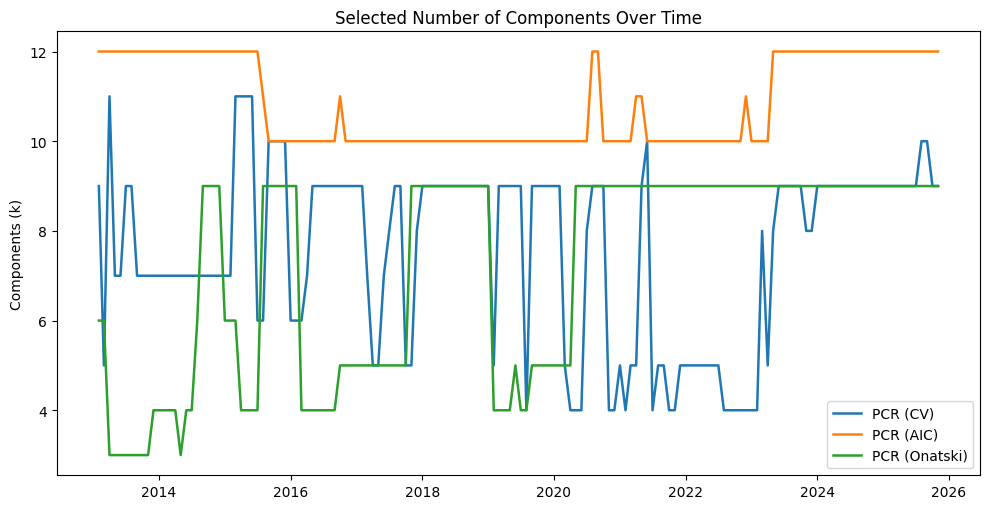

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Merge into a single DataFrame
k_cv_ts = cv_results_df.groupby("month", as_index = False)["k_cv"].first()
k_aic_ts = aic_results_df.groupby("month", as_index = False)["k_aic"].first()
k_onatski_ts = onatski_results_df.groupby("month", as_index = False)["k_onatski"].first()

k_ts = (
    k_cv_ts
    .merge(k_aic_ts, on = "month", how = "inner")
    .merge(k_onatski_ts, on = "month", how = "inner")
    .sort_values("month")
)
k_ts["month"] = k_ts["month"].dt.to_timestamp()

# Plot
fig, ax = plt.subplots(figsize = (10, 5.2))

ax.plot(k_ts["month"], k_ts["k_cv"], label = "PCR (CV)", linewidth = 1.8)
ax.plot(k_ts["month"], k_ts["k_aic"], label = "PCR (AIC)", linewidth = 1.8)
ax.plot(k_ts["month"], k_ts["k_onatski"], label = "PCR (Onatski)", linewidth = 1.8)

ax.set_title("Selected Number of Components Over Time")
ax.set_xlabel("")
ax.set_ylabel("Components (k)")

ax.legend(loc = "lower right")
plt.tight_layout()
plt.show()

## Cumulative Squared Prediction Error

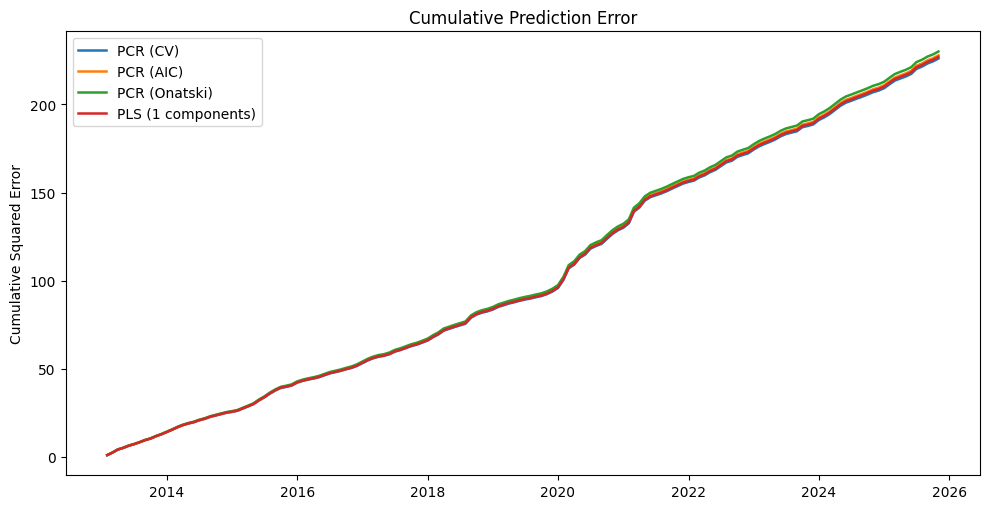

In [11]:
# Prepare for plotting cumulative error over time
def cumulative_error(df):
    df = df.copy()
    df["squared_error"] = (df["y_true"] - df["y_pred"])**2

    monthly = df.groupby("month", as_index = False)["squared_error"].mean()

    monthly["cum_error"] = monthly["squared_error"].cumsum()
    monthly["cum_error"] = monthly["cum_error"]/monthly["cum_error"].iloc[0]

    return monthly

cv_cum_error = cumulative_error(cv_results_df)
aic_cum_error = cumulative_error(aic_results_df)
onatski_cum_error = cumulative_error(onatski_results_df)
pls_cum_error = cumulative_error(pls_results_df)

for df in [cv_cum_error, aic_cum_error, onatski_cum_error, pls_cum_error]: 
    df["month"] = df["month"].dt.to_timestamp()

# Plot
fig, ax = plt.subplots(figsize = (10, 5.2))

ax.plot(cv_cum_error["month"], cv_cum_error["cum_error"], label = "PCR (CV)", linewidth = 1.8)
ax.plot(aic_cum_error["month"], aic_cum_error["cum_error"], label = "PCR (AIC)", linewidth = 1.8)
ax.plot(onatski_cum_error["month"], onatski_cum_error["cum_error"], label = "PCR (Onatski)", linewidth = 1.8)
ax.plot(pls_cum_error["month"], pls_cum_error["cum_error"], label = "PLS (1 components)", linewidth = 1.8)

ax.set_title("Cumulative Prediction Error")
ax.set_xlabel("")
ax.set_ylabel("Cumulative Squared Error")

ax.legend(loc = "upper left")
plt.tight_layout()
plt.show()

## Top Loadings / Weights Comparison

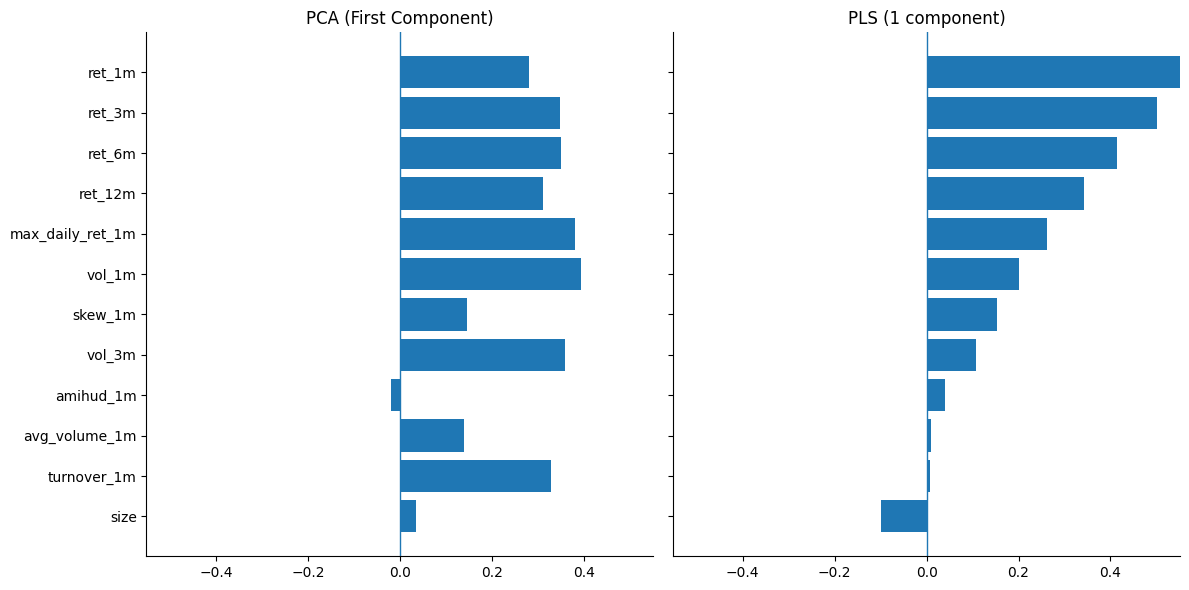

In [15]:
# PCA weights
pca = PCA(n_components = 1)
pca.fit(x_train)
pca_weights = pca.components_[0]

# PLS weights
pls = PLSRegression(n_components = 1)
pls.fit(x_train, y_train)
pls_weights = pls.x_weights_.ravel()

df_weights = pd.DataFrame({
    "feature": predictors, 
    "PCA (PC1)": pca_weights, 
    "PLS (1 component)": pls_weights
})

df_plot = df_weights.sort_values(
    "PLS (1 component)", ascending = True
)

# Plot
fig, axes = plt.subplots(1, 2, figsize = (12, 6), sharey = True)

max_val = max(
    abs(df_plot["PCA (PC1)"]).max(), 
    abs(df_plot["PLS (1 component)"]).max()
)
axes[0].set_xlim(-max_val, max_val)
axes[1].set_xlim(-max_val, max_val)

axes[0].barh(df_plot["feature"], df_plot["PCA (PC1)"])
axes[0].set_title("PCA (First Component)")

axes[1].barh(df_plot["feature"], df_plot["PLS (1 component)"])
axes[1].set_title("PLS (1 component)")

for ax in axes:
    ax.axvline(0, linewidth = 1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()